In [ ]:
import pandas as pd #Lương Nhật Hào - 2374802010128
import numpy as np

PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

1. Viết hàm load_data() để tải dữ liệu lên ứng dụng. Sau đó, hiển thị ra màn hình 10 dòng
đầu tiên.

In [ ]:
def load_data():
    df = pd.read_csv('/content/titanic_disaster.csv')
    display(df.head(10))
    return df
titanic_df = load_data()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


2. Thống kê dữ liệu thiếu trên các biến số và trực quan hóa dữ liệu thiếu bằng biểu đồ (Heat
map). Hãy cho nhận xét về tình trạng thiếu dữ liệu Age, Cabin và Embarked

=== THỐNG KÊ DỮ LIỆU THIẾU ===
Số lượng giá trị thiếu theo từng cột:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Tỷ lệ thiếu dữ liệu (%):
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Tổng số dòng: 891
Tổng số cột: 12


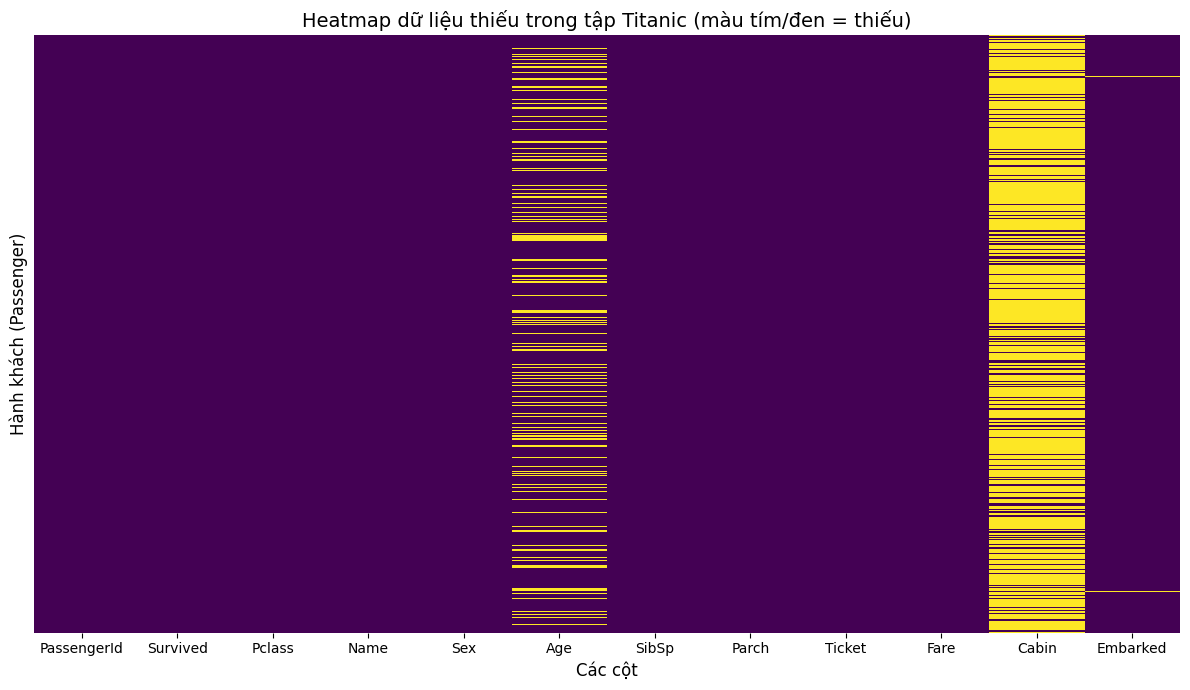

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def missing_analysis(df):
    print("=== THỐNG KÊ DỮ LIỆU THIẾU ===")
    print("Số lượng giá trị thiếu theo từng cột:")
    print(df.isnull().sum())
    print("\nTỷ lệ thiếu dữ liệu (%):")
    missing_ratio = (df.isnull().sum() / len(df) * 100).round(2)
    print(missing_ratio)
    print(f"\nTổng số dòng: {len(df)}")
    print(f"Tổng số cột: {df.shape[1]}")
    plt.figure(figsize=(12, 7))
    sns.heatmap(df.isnull(),
                cbar=False,
                cmap='viridis',          # màu vàng = có dữ liệu, tím/đen = thiếu
                yticklabels=False)       # ẩn nhãn dòng để heatmap rõ hơn
    plt.title('Heatmap dữ liệu thiếu trong tập Titanic (màu tím/đen = thiếu)', fontsize=14)
    plt.xlabel('Các cột', fontsize=12)
    plt.ylabel('Hành khách (Passenger)', fontsize=12)
    plt.tight_layout()
    plt.show()
df = pd.read_csv('/content/titanic_disaster.csv')   # thay đường dẫn nếu cần
missing_analysis(df)

Nhận xét:
Cabin thiếu rất nhiều (hơn 77%), hầu như không dùng được cho phân tích chi tiết, nên xử lý bằng "Unknown" hoặc drop cột nếu không cần.
Age thiếu ~20%, có thể impute (thay thế) bằng mean/median theo nhóm để giữ thông tin.
Embarked thiếu rất ít (2 dòng), có thể thay bằng mode ('S') hoặc drop 2 dòng.

3. Xử lý tên cột tên Name, tách ra làm 2 cột: firstName và secondName. Lưu ý: Sau khi
tách cột xong thì xóa luôn cột Name


In [9]:
df[['firstName', 'secondName']] = df['Name'].str.split(',', expand=True)
df = df.drop('Name', axis=1)
display(df[['firstName', 'secondName']].head())

,firstName,secondName
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry


4. Xứ lý rút gọn kích thước dữ liệu trên cột Sex như sau: thay thế male → M và female → F

In [10]:
df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})
display(df['Sex'].head())

,Sex
0,M
1,F
2,F
3,F
4,M


5. Xử lý dữ liệu thiếu trên biến Age bằng cách thay thế bằng giá trị trung bình tuổi: Hãy đưa
ra quyết định dùng giá trị trung bình tuổi toàn bộ hành khách hay theo từng nhóm hạng
vé (hạng hành khách: Pclass). Ta tiến hành làm các bước sau

a. Sử dụng Seaborn để vẽ biểu đồ (Box plot) trực quan dữ liệu để xác định phân
phối tuổi trên từng hạng hành khách. Nhận xét về tuổi trung bình giữa các nhóm
hành khách. Từ đó đưa ra quyết định cách thay thế giá trị tuổi bị thiếu.
BÀI TẬP THỰC HÀNH MÔN NHẬP MÔN PHÂN TÍCH DỮ LIỆU VÀ HỌC SÂU
12


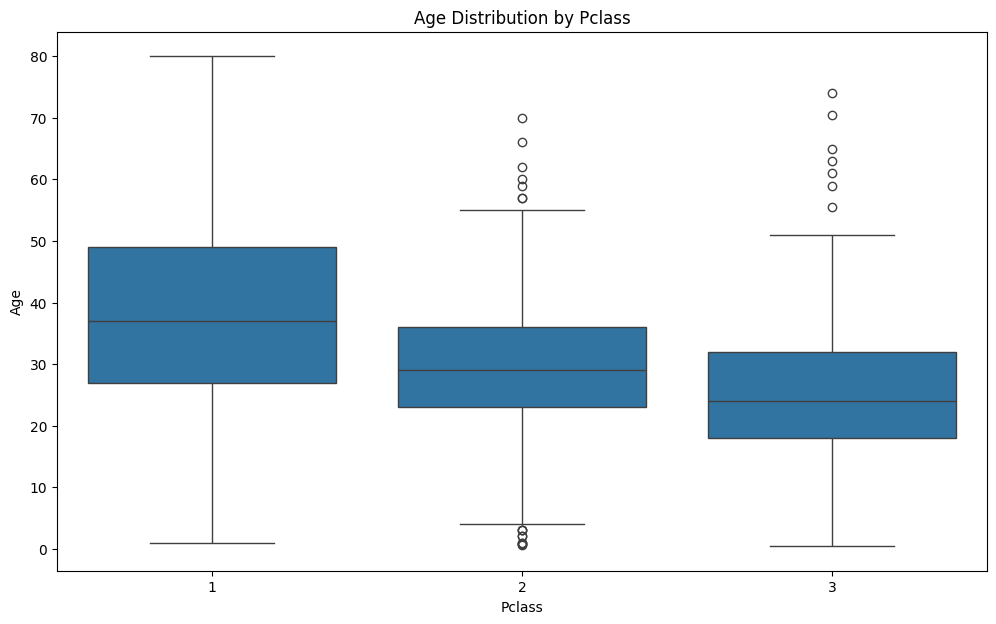

In [13]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Age Distribution by Pclass')
plt.show()

b. Tiến hành thay thế giá trị Age bị thiếu. Sau đó, hiển thị kết quả dạng bảng và trực
quan dữ liệu đã xử lý thiếu cho cột’Age’ bằng biểu đồ Heat map.


/tmp/ipython-input-1231064616.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/tmp/ipython-input-1231064616.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


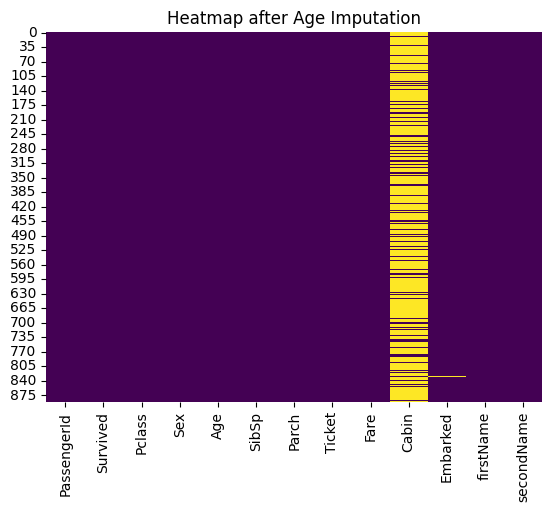

In [14]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return df[df['Pclass'] == 1]['Age'].mean()
        elif Pclass == 2:
            return df[df['Pclass'] == 2]['Age'].mean()
        else:
            return df[df['Pclass'] == 3]['Age'].mean()
    else:
        return Age

df['Age'] = df[['Age', 'Pclass']].apply(impute_age, axis=1)

sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap after Age Imputation')
plt.show()

6. Xây dựng biến số Agegroup có thang đo thứ tự được ánh xạ theo thang đo khoảng dựa
trên độ tuổi của hành khách như sau: (age =< 12] → Kid; (12, 18]: Teen, (18, 60]: Adult
và ( age > 60): Older

In [15]:
bins = [0, 12, 18, 60, 200]
labels = ['Kid', 'Teen', 'Adult', 'Older']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

display(df[['Age', 'AgeGroup']].head())

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


7. Tiến hành thêm đặc trưng về danh xưng (namePrefix) trong xã hội bằng cách tách Mr,
Mrs, Miss, Master ra khỏi “secondName”

In [16]:
df['namePrefix'] = df['secondName'].apply(lambda x: x.split('.')[0].strip())
display(df['namePrefix'].value_counts())

,count
namePrefix,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


8. Khai thác thêm thông tin số lượng thành viên đi theo nhóm thân quen (familySize) đối
với mỗi hành khách trên chuyến hải trình; family size = 1+ SibSp + Parch

In [17]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
print(df[['SibSp', 'Parch', 'familySize']].head())

   SibSp  Parch  familySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


9. Tạo thêm đặc trưng ‘Alone’ để xác định hành khách đi theo nhóm hay cá nhân bằng cách
dựa trên familySize như sau: Nếu familySize = 0 thì giá trị Alone = 1 và ngược lại là 0.

In [18]:
df['Alone'] = 0
df.loc[df['familySize'] == 1, 'Alone'] = 1
display(df[['familySize', 'Alone']].head())

,familySize,Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


10. Tiến hành tách loại cabin (typeCabin) mà hành khách ở để lọc và phân tích đặc tính
cabin. Loại cabin được kí hiệu bởi chữ cái đầu tiên. Lưu ý: Đối với dữ liệu cabin bị thiếu
thì thay thế bằng “Unknown”


In [19]:
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['typeCabin'] = df['Cabin'].apply(lambda x: x[0])
display(df['typeCabin'].value_counts())

,count
typeCabin,
U,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


11. Loại bỏ dữ liệu thừa đối với các hành khách xuất hiện trong cả 2 tập dữ liệu huấn luyện
(train.csv) và đánh giá (test.csv). Ưu tiên giữ lại dữ liệu trong tập huấn luyện.


In [20]:
print(f"Số dòng trước khi xóa trùng: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"Số dòng sau khi xóa trùng: {len(df)}")

Số dòng trước khi xóa trùng: 891
Số dòng sau khi xóa trùng: 891


PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA

12. Trực quan thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính.

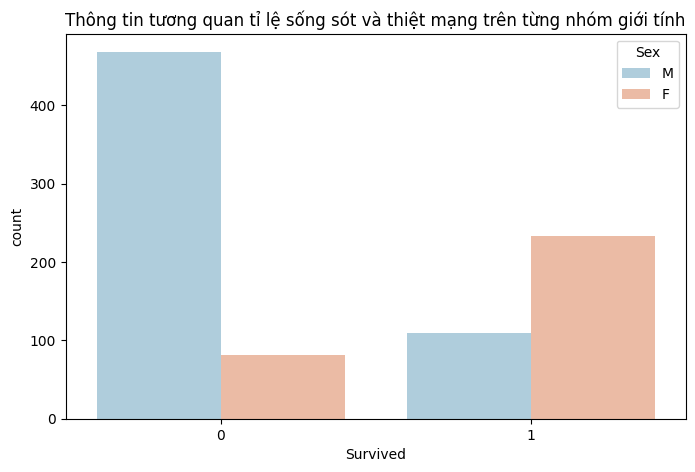

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Sex', data=df, palette='RdBu_r')
plt.title('Thông tin tương quan tỉ lệ sống sót và thiệt mạng trên từng nhóm giới tính')
plt.show()

13. Trực quan thông tin hành khách sống sót trên từng nhóm phân loại hành khách (Pclass).

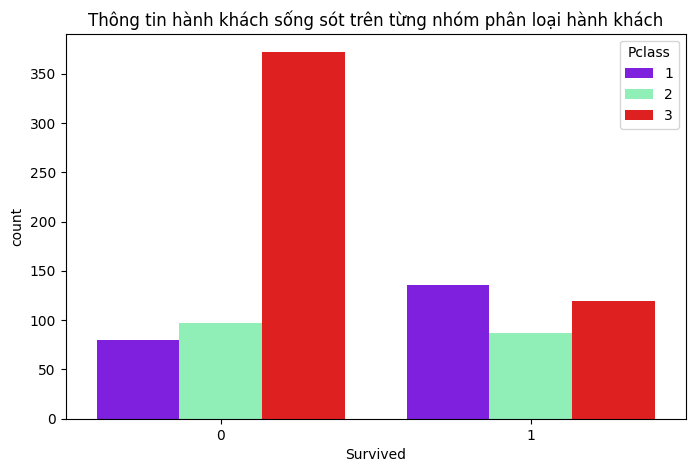

In [29]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Survived', hue='Pclass', data=df, palette='rainbow')
plt.title('Thông tin hành khách sống sót trên từng nhóm phân loại hành khách')
plt.show()

14. Trực quan thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác

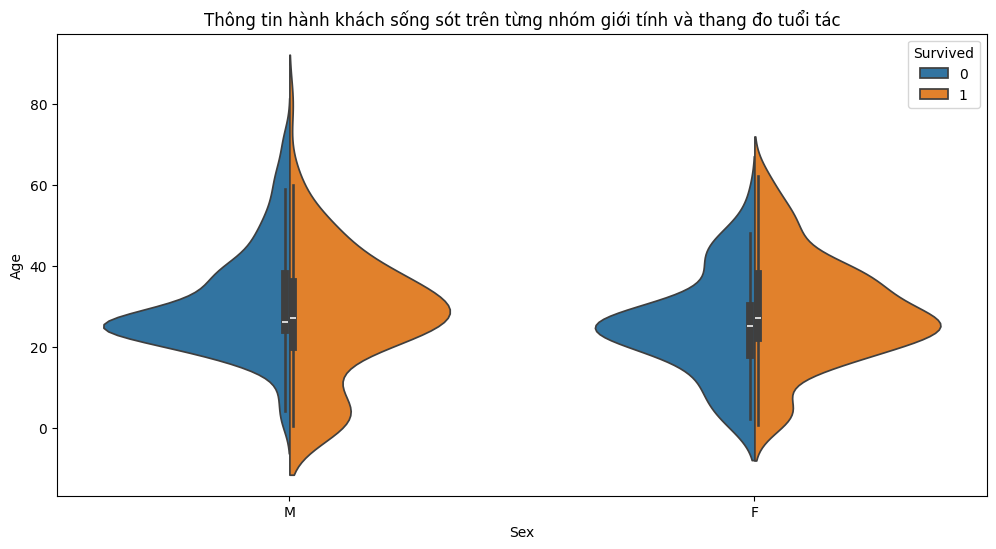

In [27]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df, split=True)
plt.title('Thông tin hành khách sống sót trên từng nhóm giới tính và thang đo tuổi tác')
plt.show()

15. Trực quan xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng

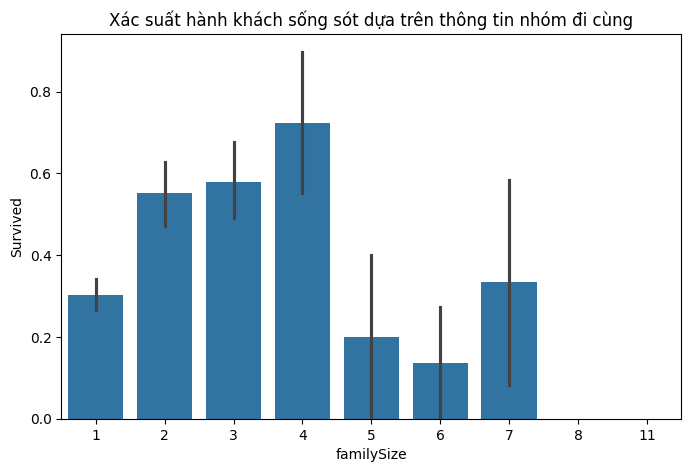

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(x='familySize', y='Survived', data=df)
plt.title('Xác suất hành khách sống sót dựa trên thông tin nhóm đi cùng')
plt.show()

16. Trực quan xác suất hành khách sống sót dựa trên thông tin giá vé


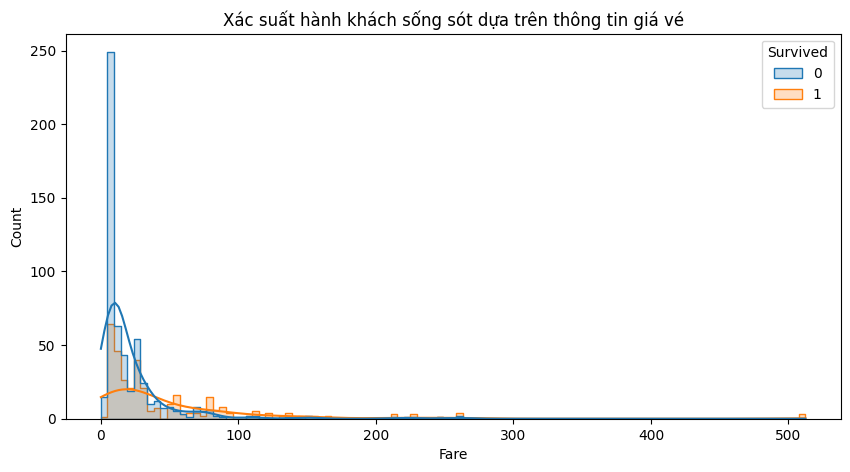

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Fare', hue='Survived', kde=True, element="step")
plt.title('Xác suất hành khách sống sót dựa trên thông tin giá vé')
plt.show()

17. Trực quan số lượng người thiệt mạng và sống sót theo phân lớp (Pclass) hành khách và
cảng sẽ cập bến.

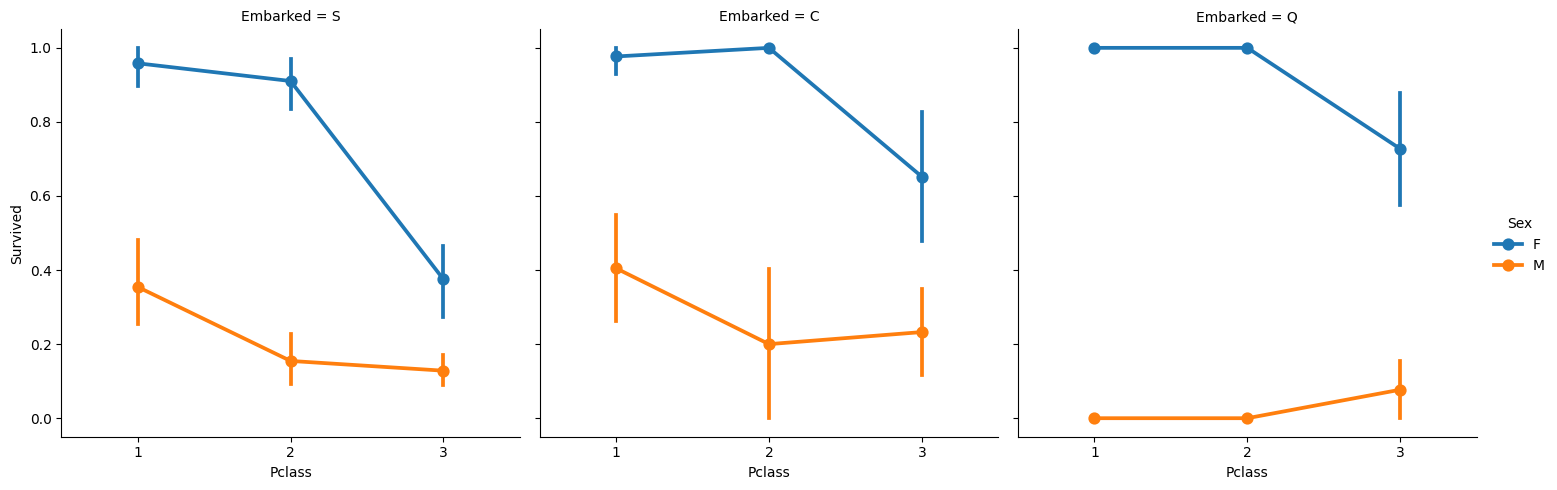

In [33]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', col='Embarked', kind='point', data=df)
plt.show()